# Proper STLF Regression using CNN and Bi-LSTM
**Based on:** "Improving Electric Energy Consumption Prediction Using CNN and Bi-LSTM" (Le et al., Applied Sciences 2019).

**Context:** Unlike the flawed DEPM paper, this implementation correctly treats the UCI dataset as a **multi-variate regression problem**. It uses CNN layers to extract spatial/feature correlations (how Voltage, Sub-meterings interact) and a Bi-LSTM to capture the forward and backward time-series trends, predicting the continuous power usage.

**Key Features of EECP-CBL:**
1. **Target:** Predict actual continuous `Global_active_power` (kW).
2. **Splitting:** Strict **chronological split** (Train: up to 2009, Test: 2010).
3. **Data Windowing:** Uses a sliding window to predict the next steps.
4. **Architecture:** Exactly 2 `1D-CNN` layers -> 2 `Bi-LSTM` layers -> 2 `Linear` (FC) layers.
5. **Metrics:** Real unscaled MAE, RMSE, MSE, and MAPE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [2]:
print('Loading data...')
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt', sep=';', 
                 na_values=['?'], dtype={'Date': str, 'Time': str})

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time']).set_index('Datetime')

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Forward fill missing values (vital for continuous time-series)
df = df.ffill().bfill()

print('Resampling to hourly frequency...')
df_h = df.resample('h').mean()

# Feature Engineering
df_h['Hour'] = df_h.index.hour
df_h['DayOfWeek'] = df_h.index.dayofweek
df_h['Month'] = df_h.index.month

df_h = df_h.dropna()
print(f'Total hourly records: {df_h.shape[0]}')

Loading data...
Resampling to hourly frequency...
Total hourly records: 34589


## 1. Chronological Split & Preprocessing
To prevent data leakage, we fit the scalers **only** on the training set (2006-2009).

In [3]:
# Define split point (End of 2009)
train_mask = df_h.index.year < 2010
test_mask = df_h.index.year >= 2010

features = df_h.columns.tolist()
target_idx = features.index('Global_active_power')

train_data = df_h.loc[train_mask].values
test_data = df_h.loc[test_mask].values

print(f'Train samples: {len(train_data)}')
print(f'Test samples: {len(test_data)}')

# We use MinMaxScaler (0 to 1) which is standard for neural networks
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit only on training data
X_train_scaled = scaler_X.fit_transform(train_data)
# We need a separate scaler for the target to inverse_transform predictions later
y_train_scaled = scaler_y.fit_transform(train_data[:, target_idx].reshape(-1, 1))

# Transform test data
X_test_scaled = scaler_X.transform(test_data)
y_test_scaled = scaler_y.transform(test_data[:, target_idx].reshape(-1, 1))

Train samples: 26671
Test samples: 7918


## 2. Sliding Window Dataset
Neural networks for time-series require 3D inputs: `(batch_size, sequence_length, features)`. We use a 24-hour lookback window.

In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = X
        self.y = y
        self.seq_len = seq_len
        
    def __len__(self):
        return len(self.X) - self.seq_len
        
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.X[idx : idx+self.seq_len]), 
                torch.FloatTensor(self.y[idx+self.seq_len]))

SEQ_LEN = 24
BATCH_SIZE = 128

train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, SEQ_LEN)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_sample, y_sample = next(iter(train_loader))
print(f'Input shape: {x_sample.shape} -> (Batch, Seq_Len, Features)')
print(f'Target shape: {y_sample.shape}')

Input shape: torch.Size([128, 24, 10]) -> (Batch, Seq_Len, Features)
Target shape: torch.Size([128, 1])


## 3. EECP-CBL Architecture
As specified in Le et al. (2019), the EECP-CBL model contains:
* **2 CNN Layers:** Applies convolutions across the sequence to capture short-term local trends and inter-feature correlations.
* **2 Bi-LSTM Layers:** Reads the CNN-extracted features both forwards and backwards in time to capture long-term dependencies.
* **2 FC Layers:** Outputs the final continuous regression value.

In [5]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, num_features, cnn_filters=64, lstm_hidden=50):
        super(CNN_BiLSTM, self).__init__()
        
        # CNN block: 2 Convolutional Layers
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Bi-LSTM block: 2 Bi-LSTM Layers
        self.lstm = nn.LSTM(
            input_size=cnn_filters*2, 
            hidden_size=lstm_hidden, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True
        )
        
        # FC block: 2 Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        # x is (batch, seq_len, features)
        # Permute for Conv1d -> (batch, features, seq_len)
        x = x.permute(0, 2, 1)
        
        # CNN Output: (batch, cnn_filters, seq_len//2)
        x = self.cnn(x)
        
        # Permute for LSTM -> (batch, seq_len//2, cnn_filters)
        x = x.permute(0, 2, 1)
        
        # LSTM Output: out=(batch, seq_len//2, lstm_hidden*2), hidden=(num_layers*2, batch, lstm_hidden)
        out, _ = self.lstm(x)
        
        # Take the output from the last time step
        last_out = out[:, -1, :]
        
        # Predict continuous value
        pred = self.fc(last_out)
        return pred

model = CNN_BiLSTM(num_features=X_train_scaled.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

CNN_BiLSTM(
  (cnn): Sequential(
    (0): Conv1d(10, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(128, 50, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 4. Training Loop

Training CNN-BiLSTM...
Epoch [1/15] - Loss: 0.011574
Epoch [2/15] - Loss: 0.008342
Epoch [3/15] - Loss: 0.007568
Epoch [4/15] - Loss: 0.007310
Epoch [5/15] - Loss: 0.007049
Epoch [6/15] - Loss: 0.006963
Epoch [7/15] - Loss: 0.006838
Epoch [8/15] - Loss: 0.006781
Epoch [9/15] - Loss: 0.006636
Epoch [10/15] - Loss: 0.006565
Epoch [11/15] - Loss: 0.006519
Epoch [12/15] - Loss: 0.006446
Epoch [13/15] - Loss: 0.006327
Epoch [14/15] - Loss: 0.006340
Epoch [15/15] - Loss: 0.006174


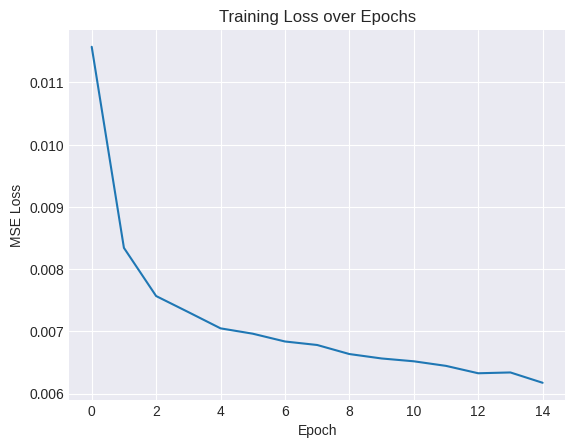

In [6]:
EPOCHS = 15

print("Training CNN-BiLSTM...")
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    avg_loss = np.mean(batch_losses)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.6f}')

plt.plot(train_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

## 5. Evaluation & Inverse Transform
We must inverse transform the predictions back to the original kilowatt scale to get real-world error metrics (RMSE/MAE).

In [7]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        predictions.extend(preds)
        actuals.extend(y_batch.numpy())

# Inverse transform to get original kW values
preds_kw = scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
actuals_kw = scaler_y.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()

# Calculate actual regression metrics
mae = mean_absolute_error(actuals_kw, preds_kw)
rmse = np.sqrt(mean_squared_error(actuals_kw, preds_kw))
mape = mean_absolute_percentage_error(actuals_kw, preds_kw)

print(f'--- Test Set Evaluation ---')
print(f'MAE:  {mae:.4f} kW')
print(f'RMSE: {rmse:.4f} kW')
print(f'MAPE: {mape:.2%}')

--- Test Set Evaluation ---
MAE:  0.3262 kW
RMSE: 0.4727 kW
MAPE: 41.30%


## 6. Visualization: Model vs. Reality
Plotting a 1-week window to see how the model tracks true power demand.

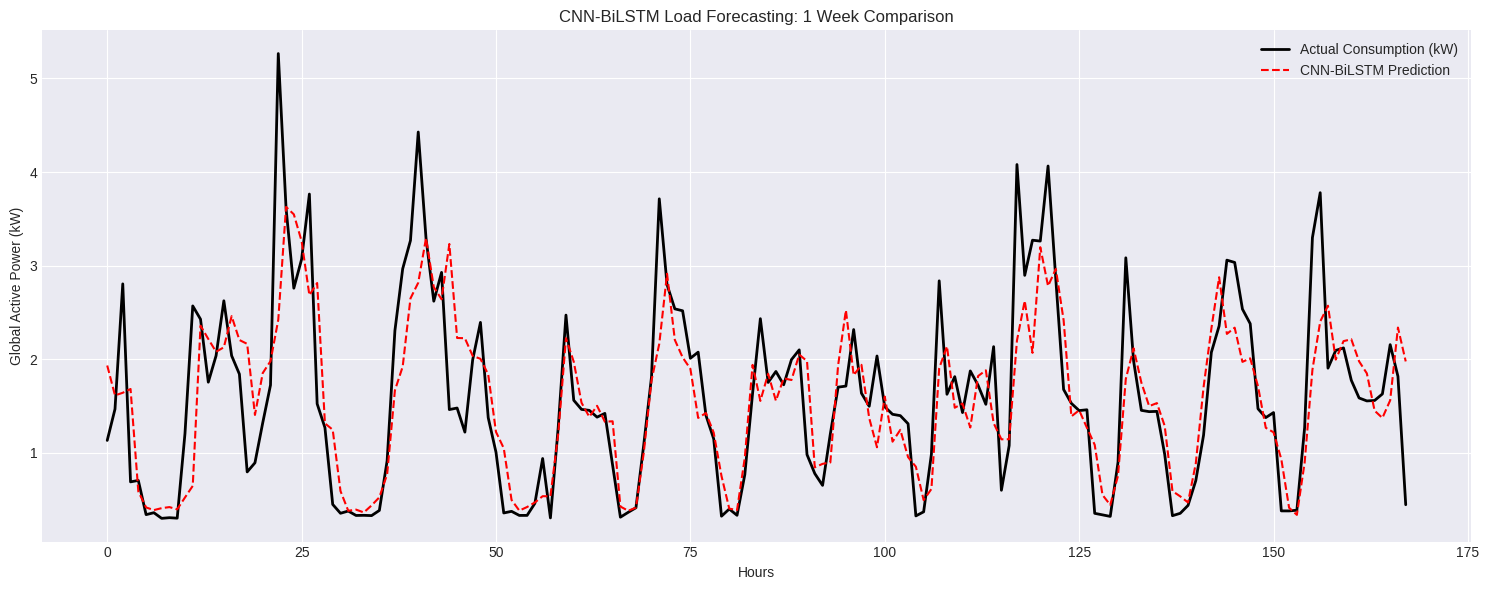

In [8]:
# Plot 1 week (168 hours)
plot_start = 500
plot_end = plot_start + 168

plt.figure(figsize=(15, 6))
plt.plot(actuals_kw[plot_start:plot_end], label='Actual Consumption (kW)', color='black', linewidth=2)
plt.plot(preds_kw[plot_start:plot_end], label='CNN-BiLSTM Prediction', color='red', linestyle='--', linewidth=1.5)

plt.title('CNN-BiLSTM Load Forecasting: 1 Week Comparison')
plt.xlabel('Hours')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()